<a href="https://colab.research.google.com/github/M-Nafay-Ali/AI_Job_Marker_Analysis/blob/main/AI_Job_Market_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


First we use "Pandas" to understand our data as it is the core feature which will lead to all the other steps
First we check some of our data to get idea of what kind of type of data it is with the help of "df.head()"
Then we use "df.info()" to check whether all the values which should be in integar or float are in numerical data type or not
Then we use ".issnull()and.sum()"consequetively so our system can count if there are some missing values in our data or not
Then we use describe method to know our data as we will be performing operation on basis of it

In [ ]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/AI_Job_Market_Trends_2026.csv")
print(df)
print("\n Now for First Few lines of data to understand data")
print(df.head())
print("\n")
print(df.info())
print("Now checking null values")
print(df.isnull().sum())
display(df.describe())

       job_id                  job_title company_size company_industry  \
0           1                AI Engineer      Startup           Retail   
1           2  Machine Learning Engineer          MNC       Technology   
2           3  Machine Learning Engineer          MNC       Technology   
3           4           Business Analyst      Startup       Healthcare   
4           5             Data Scientist          MNC       Healthcare   
...       ...                        ...          ...              ...   
10340   10341              Data Engineer      Startup       Technology   
10341   10342               Data Analyst       Medium       Healthcare   
10342   10343  Machine Learning Engineer      Startup        Education   
10343   10344              Data Engineer          MNC       E-commerce   
10344   10345                AI Engineer      Startup        Education   

         country remote_type experience_level  years_experience  \
0         Canada      Remote           Senio

,job_id,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,5173.000000,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,2986.488601,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,2587.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,5173.000000,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,7759.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,10345.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


Now we  create a heatmap to see which skill has the highest correlation with a high salary (correlational heat map)
As we took all the skills given in our data and compare them on the basis of salary as in the given graph it is clear that
0.24 is highest (deep learning)
0.23 is second highest(machine learning)
So these two skills play a vital role in salary packages as it can increase salary globally and nationally both

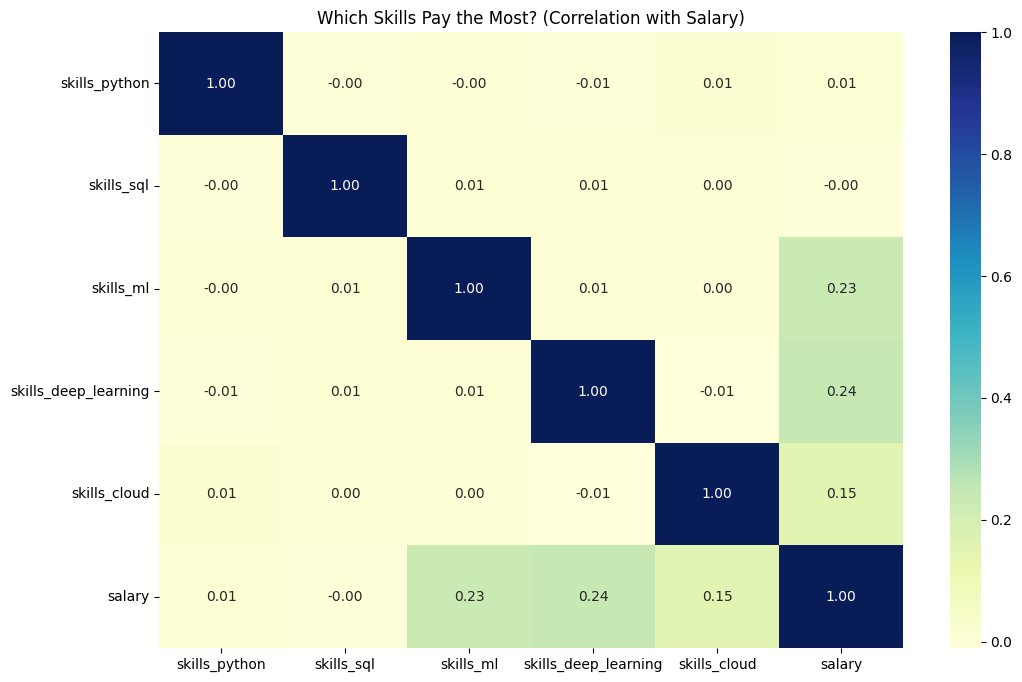

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecting skill columns and salary
skill_cols = ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud', 'salary']
plt.figure(figsize=(12, 8))

sns.heatmap(df[skill_cols].corr(), annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Which Skills Pay the Most? (Correlation with Salary)')
plt.show()

Now this graph will show the comparison between the salaries of "remote site" and "on-site" as it is one of the hot topic of 2026 as we create a interactive graph with the help of Plotly

In [24]:
import plotly.express as px

fig = px.box(df, x="remote_type", y="salary",
             color="experience_level",
             title="Salary Distribution by Remote Status & Experience",
             points="all", # Shows every single job posting as a dot
             template="plotly_dark")
fig.show()


And since we have 10,000+ entries we need to determine top 10 highest paying jobs in global scale we again use plotlylibrary to create Horizontal Bar chart in which we use the top job titles and calculate their average salary
As it clearly shows that highest paying role in job market 2026 are "Ml engineer" and "Ai engineer" while analyst , scientist etc roles are also high paying with stable career options

In [23]:
import plotly.express as px

# 1. Group by Job Title and find the average salary
top_jobs = df.groupby('job_title')['salary'].mean().sort_values(ascending=False).head(10).reset_index()

# 2. Create a Horizontal Bar Chart
fig_jobs = px.bar(top_jobs,
                  x='salary',
                  y='job_title',
                  orientation='h',
                  title='Top 10 Highest Paying Data Job Titles',
                  color='salary',
                  color_continuous_scale='Viridis',
                  template='plotly_dark')

fig_jobs.show()